# Imports

In [2]:
import os
import numpy as np
import pandas as pd
import transformers
import tensorflow as tf
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt
import datasets
from datasets import load_dataset
import tables
import torch
import keras

# Data

In [3]:
ds = load_dataset("prithivMLmods/OpenScene-Classification")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dataset/OpenScene-Classification.parquet:   0%|          | 0.00/248M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16345 [00:00<?, ? examples/s]

In [4]:
ds_raw = ds['train']
ds_raw = ds_raw.train_test_split(test_size=0.2, seed=42)

In [5]:
train_ds = ds_raw['train']
test_ds = ds_raw['test']

In [6]:
print(f'train_ds: {len(train_ds)} | test_ds: {len(test_ds)}')

train_ds: 13076 | test_ds: 3269


# Backbone

In [7]:
backbone = transformers.AutoModel.from_pretrained("google/vit-base-patch32-224-in21k")
backbone = backbone.to('cuda')

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

In [8]:
processor = transformers.AutoImageProcessor.from_pretrained("google/vit-base-patch32-224-in21k")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


# Feature extraction

In [9]:
def extraction(data: datasets.Dataset, path: str, batch_size: int = 64):
    with tables.open_file(path, "w") as file, torch.no_grad():
        array = file.create_carray(file.root, "embeddings", tables.Float32Atom(), shape=(len(data), 768), filters=tables.Filters(3, "blosc:lz4"))
        answers = file.create_carray(file.root, "labels", tables.Int8Atom(), shape=(len(data),), filters=tables.Filters(3, "blosc:lz4"))

        for i in tqdm.trange(0, len(data), batch_size):
            images = data[i:i + batch_size]["image"]
            images = processor(images, return_tensors='pt').to(backbone.device)
            features = backbone(**images).pooler_output.cpu().numpy()
            array[i:i + batch_size] = features
            answers[i:i + batch_size] = np.array(data[i:i + batch_size]["label"])

# Prepare train/test data

In [10]:
extraction(train_ds, 'train_ds.hdf5')
extraction(test_ds, 'test_ds.hdf5')

  0%|          | 0/205 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

In [11]:
train_file = tables.open_file("train_ds.hdf5", "r")
test_file = tables.open_file("test_ds.hdf5", "r")

In [12]:
class Dataset(keras.utils.PyDataset):
    def __init__(self, dataset: tables.File, batch_size: int = 64, shuffle: bool = False, **kwargs):
        super().__init__(**kwargs)
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng()

        self.idx = np.arange(len(self.dataset.root["labels"]))
        self.on_epoch_end()

    def __len__(self) -> int:
        return (len(self.idx) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, idx: int) -> tuple[np.ndarray, np.ndarray]:
        start_idx = idx * self.batch_size
        end_idx = (idx + 1) * self.batch_size
        idx = self.idx[start_idx:end_idx]

        return self.dataset.root["embeddings"][idx, :], self.dataset.root["labels"][idx]

    def on_epoch_end(self) -> None:
        if self.shuffle:
            self.idx = self.rng.choice(self.idx, size=len(self.idx), replace=False)

Prepare `tf.data.Dataset` or some other way for the data to be used during training.

In [13]:
train_dataset = Dataset(
    train_file,
    batch_size=32,
    shuffle=True,
)

In [14]:
test_dataset = Dataset(test_file,)

# Build the model

In [15]:
inputs = keras.layers.Input((768,), name="input")
x = keras.layers.Dense(64, name="dense1")(inputs)
x = keras.layers.Dense(10, name="output")(x)

In [16]:
model = keras.Model(inputs=inputs, outputs=x, name="model")

In [17]:
model.compile(
    optimizer="adam",
    metrics=["accuracy"],
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

In [18]:
model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,866 (194.79 KB)

 Trainable params: 49,866 (194.79 KB)

 Non-trainable params: 0 (0.00 B)

# Train the model

In [19]:
model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint("cls_head_v2.keras", save_best_only=True, monitor='val_loss', mode="min"),
    ],
)

Epoch 1/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8777 - loss: 0.3930 - val_accuracy: 0.9370 - val_loss: 0.1854
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9488 - loss: 0.1476 - val_accuracy: 0.9403 - val_loss: 0.1640
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9567 - loss: 0.1231 - val_accuracy: 0.9468 - val_loss: 0.1526
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9548 - loss: 0.1243 - val_accuracy: 0.9462 - val_loss: 0.1588
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9644 - loss: 0.1000 - val_accuracy: 0.9446 - val_loss: 0.1636
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9681 - loss: 0.0887 - val_accuracy: 0.9434 - val_loss: 0.1679
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9669 - loss: 0.0937 - val_accuracy: 0.9443 - val_loss: 0.1682
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9701 - loss: 0.0854 - val_accuracy: 0

# Evaluation

Evalute the model on test data.

In [20]:
model.evaluate(test_dataset)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9388 - loss: 0.1796


[0.17634569108486176, 0.9464668035507202]

Plot confusion matrix.

In [21]:
labels = {
    0: "buildings",
    1: "forest",
    2: "glacier",
    3: "mountain",
    4: "sea",
    5: "street"
}

In [22]:
y_pred = model.predict(test_file.root["embeddings"][:], verbose=False).argmax(axis=-1)
y_true = test_file.root["labels"][:]

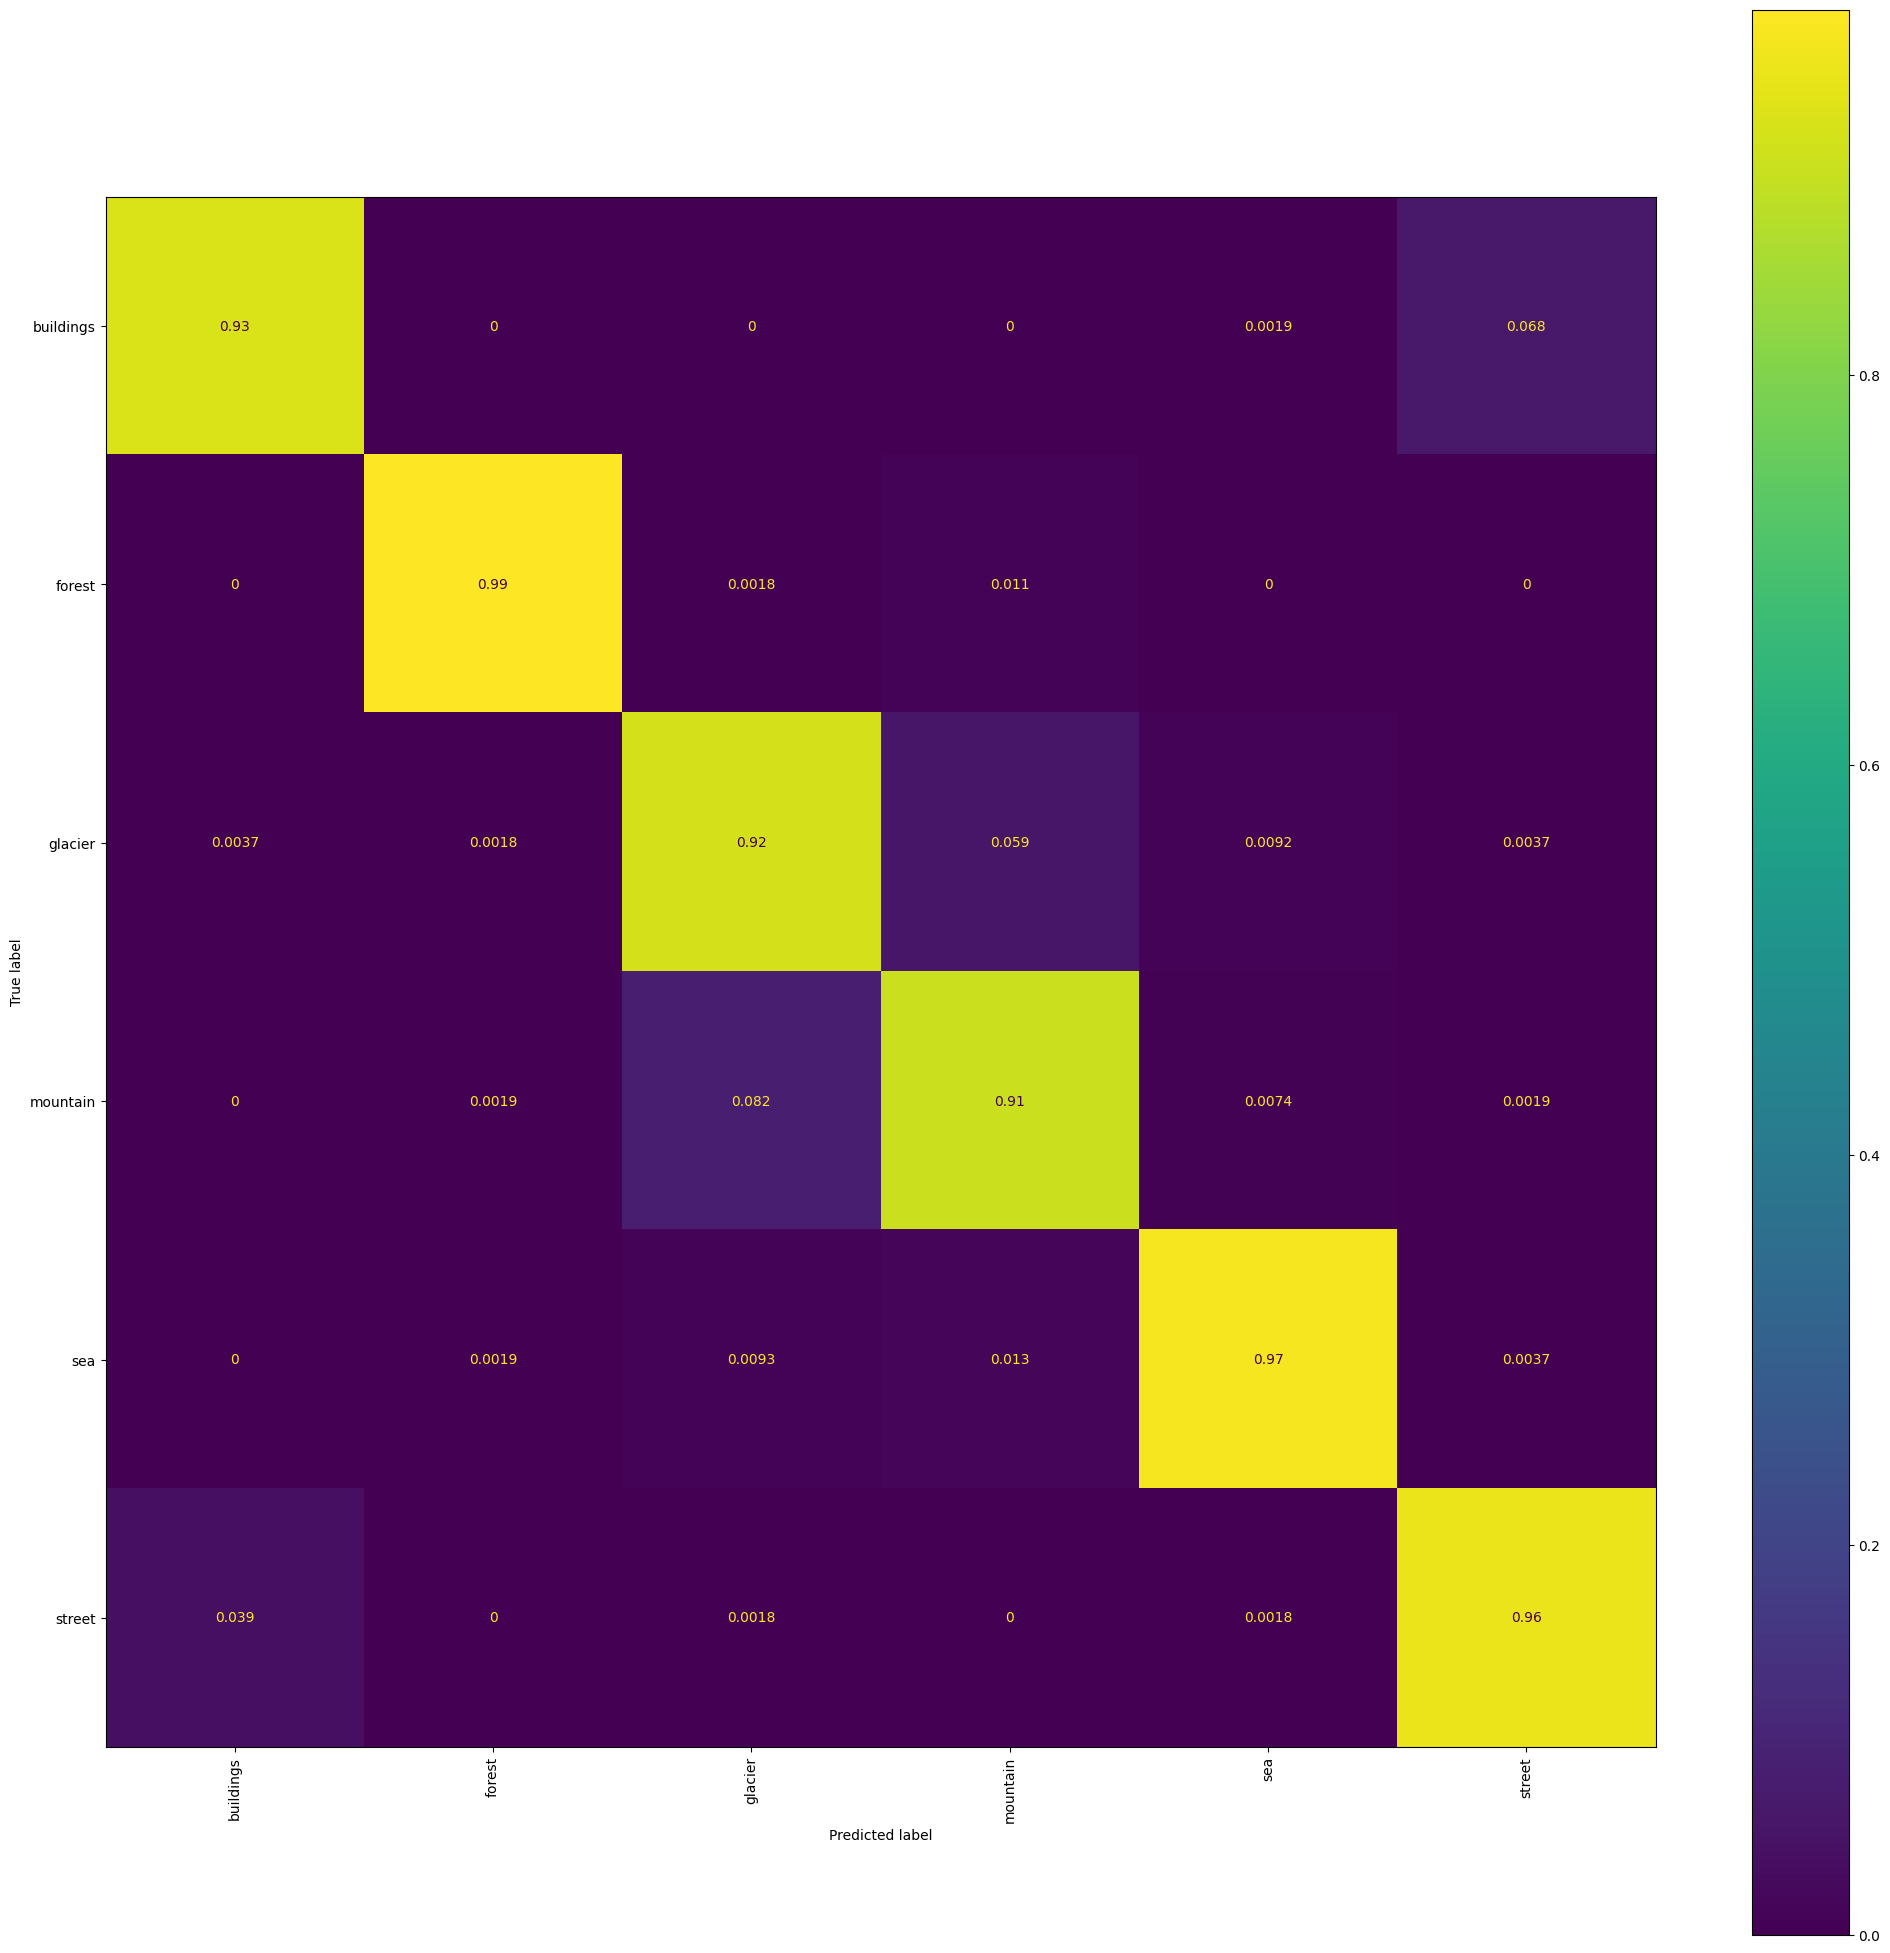

In [23]:
_, ax = plt.subplots(figsize=(25, 25))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    ax=ax,
    xticks_rotation=90,
    normalize="true",
    display_labels=labels.values()
)

In [24]:
def plot_clust(dataset: tables.File, n_classes: int, dim_reducer, cls_map: dict[int, str]) -> None:
    embeddings = np.array(dataset.root["embeddings"])
    labels = np.array(dataset.root["labels"])

    emb_reduce = dim_reducer(n_components=2).fit_transform(embeddings)

    plt.figure(figsize=(10, 10))
    for idx in range(n_classes):
        cls_embs = emb_reduce[np.where(labels == idx)]
        plt.scatter(cls_embs[:, 0], cls_embs[:, 1], label=cls_map[idx])

    plt.legend()
    plt.show()

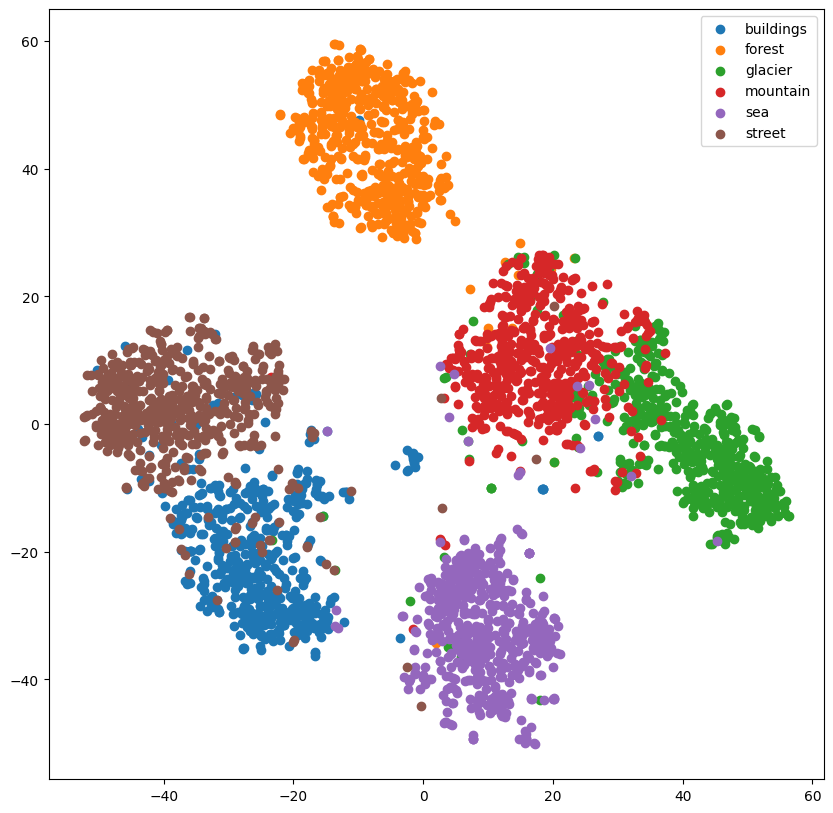

In [28]:
plot_clust(test_file, 6, sklearn.manifold.TSNE, labels)

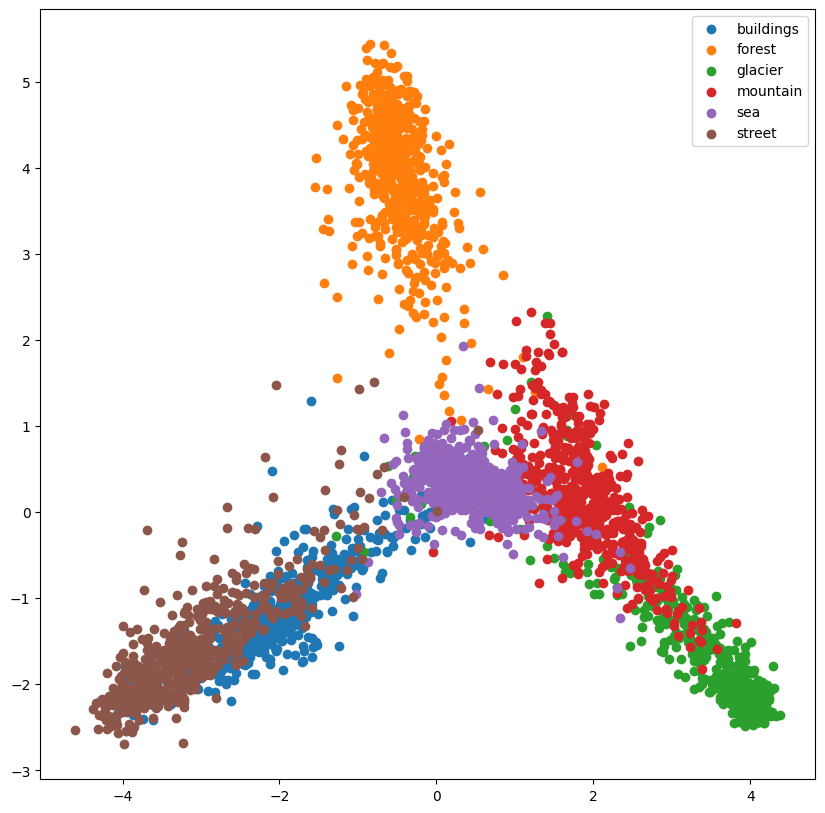

In [29]:
plot_clust(test_file, 6, sklearn.decomposition.PCA, labels)